In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import tqdm
import numpy as np
import pandas as pd

from src.encode import position_planes, uci_to_index
from src.dataclass import preprocess_csv_to_tensors, ChessDataset
from src.dataset import load_pgn, load_multiple_pgns, create_csv_dataset
from src.model import ConvNet

In [ ]:

games = load_multiple_pgns(num_pgns=26)
create_csv_dataset(games, name="train")

In [ ]:
preprocess_csv_to_tensors("data/csv/train.csv", "data/pt/train.pt")

In [4]:
dataset = ChessDataset("data/pt/train.pt")
loader = torch.utils.data.DataLoader(
    dataset, 
    batch_size=256, 
    shuffle=True, 
    pin_memory=True, 
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvNet(input_channels=12, output_size=4544)
model = model.to(device)

In [ ]:
policy_loss = torch.nn.CrossEntropyLoss()
value_loss = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# If the model isn't loaded training starts at 0 epochs
epoch = 0

In [ ]:
print(torch.cuda.memory_allocated() / 1024**2, "MB")
print(torch.cuda.max_memory_allocated() / 1024**2, "MB")

In [ ]:
# Step 6: Train the model
EPOCHS = 100
train_losses = []
scaler = torch.GradScaler()

for epoch in tqdm.trange(epoch, EPOCHS + 1):
    model.train()
    total_policy_loss = 0

    for boards, labels in loader:
        boards = boards.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            policy = model(boards)
            p_loss = policy_loss(policy, labels)

            loss = p_loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_policy_loss += p_loss.item()

    avg_p_loss = total_policy_loss / len(loader)

    print(f"Epoch {epoch+1}/{EPOCHS+1} - Policy Loss: {avg_p_loss:.4f}")

    train_losses.append(avg_p_loss)
    torch.save({
    "train_losses": train_losses,
    }, "data/loss/loss_log_version_a.pt")

    
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, f"models/model_version_a/model.{epoch}.pth")

    print(f"Checkpoint saved at epoch {epoch}")

In [9]:
import matplotlib.pyplot as plt

# Load the log
loss_log = torch.load(
    "data/loss/loss_log.pt",
    map_location="cpu"
)

In [11]:
train_losses = loss_log["train_losses"]
print(train_losses)
print(len(train_losses))

[4.151448246371157, 3.363704221231398, 3.2000659734557377, 3.1055599236766653, 3.0398060366867514, 2.9909612113333464, 2.950268451129814, 2.9165917257655654, 2.8867477674362325, 2.8610609139118544, 2.8387593287372006, 2.819081138809102, 2.8014902321082342, 2.7853534015965105, 2.7694428323307854, 2.7555110649111008, 2.7422278703484952, 2.7295828387762455, 2.7171999680591727, 2.706224764738565, 2.6946506731638715, 2.6836951044283026, 2.6741708622699716, 2.663996531368296, 2.6549772194718706, 2.6467914089883546, 2.6393037950548615, 2.6315372870987557, 2.625348742184472, 2.6190670624383627, 2.613566260923605, 2.6075117048652654, 2.602817499432185, 2.5969141415717405, 2.5919343205410086, 2.5880231255355843, 2.5841365817389668, 2.579455998236766, 2.575043290346579, 2.572138922475589, 2.568023039434538, 2.5651757473810437, 2.5613550435310604, 2.559062535581223, 2.5554446864750995, 2.5525649861669195, 2.550157880120439, 2.5478236215388925, 2.5453281111025428, 2.54308939406844, 2.54087262649281

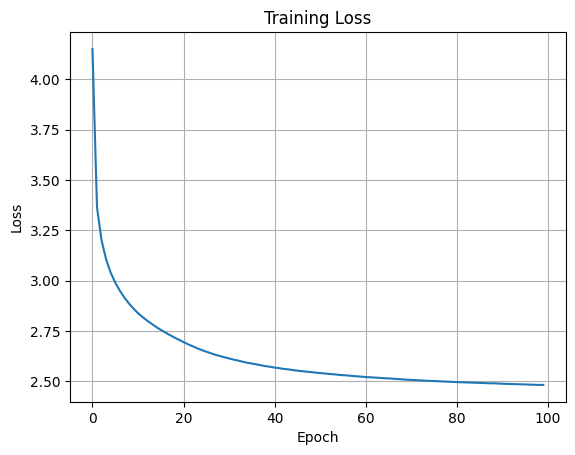

In [12]:
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()